---
title: Linear Regression and Uncertainty Quantification
---

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

### Squares Function Plotting

Given some data $y_1, \dots, y_n$ that are not all equal, consider the squares function: 
\begin{align*}
   S(\theta) := \sum_{i=1}^n (y_i - \theta)^2. 
\end{align*}
This function will be minimized at $\hat{\theta} = (y_1 + \dots + y_n)/n$. The code below plots this function for some data $y_1, \dots, y_n$.

In [69]:
y = np.array([1, 0, 2, -2, 5])
theta_hat = np.mean(y)
#Below is the squares function S(theta) := sum_i (y_i - theta)^2
def S(theta):
    return np.sum((y - theta)**2)

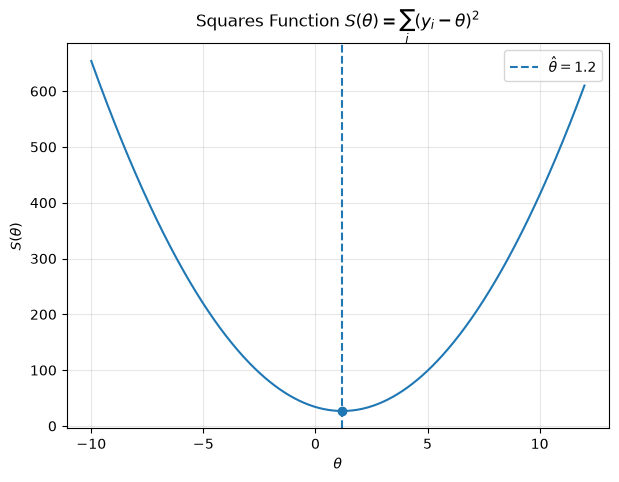

In [70]:
# Plot S(theta)
theta = np.linspace(-10, 12, 500)
S_values = np.array([S(t) for t in theta])

plt.figure(figsize=(7, 5))
plt.plot(theta, S_values)
plt.axvline(theta_hat, linestyle="--", label=rf"$\hat{{\theta}}={theta_hat}$")
plt.scatter(theta_hat, S(theta_hat), zorder=3)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$S(\theta)$")
plt.title(r"Squares Function $S(\theta)=\sum_i (y_i-\theta)^2$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Next we plot the function $S(\hat{\theta})/S(\theta)$ as a function of $\theta$. 

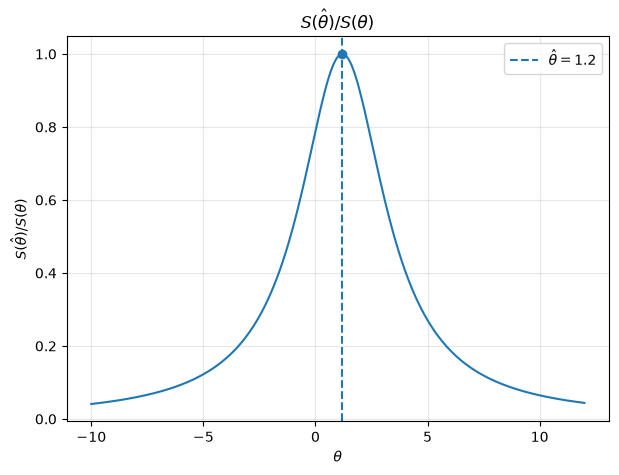

In [71]:
# Plot S(theta_hat) / S(theta)
theta = np.linspace(-10, 12, 500)
ratio = np.array([S(theta_hat) / S(t) for t in theta])

plt.figure(figsize=(7, 5))
plt.plot(theta, ratio)
plt.axvline(theta_hat, linestyle="--",
            label=rf"$\hat{{\theta}}={theta_hat}$")
plt.scatter(theta_hat, 1, zorder=3)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$S(\hat{\theta})/S(\theta)$")
plt.title(r"$S(\hat{\theta})/S(\theta)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Below we plot $\left(S(\hat{\theta})/S(\theta) \right)^m$ for $m \geq 1$. When $m$ becomes large, this function becomes quite sharply concentrated around $\hat{\theta}$. 

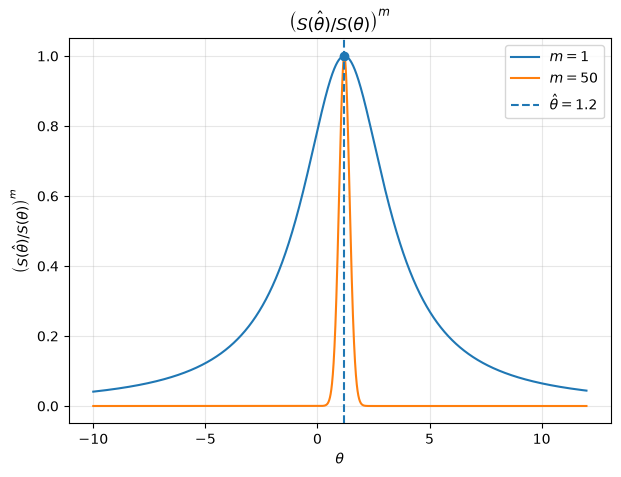

In [74]:
theta = np.linspace(-10, 12, 5000)

m = 50

ratio_1 = np.array([S(theta_hat) / S(t) for t in theta])
ratio_m = ratio_1**m

plt.figure(figsize=(7, 5))

plt.plot(theta, ratio_1, label=r"$m=1$")
plt.plot(theta, ratio_m, label=rf"$m={m}$")

plt.axvline(theta_hat, linestyle="--",
            label=rf"$\hat{{\theta}}={theta_hat}$")

plt.scatter(theta_hat, 1, zorder=3)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$\left(S(\hat{\theta})/S(\theta)\right)^m$")
plt.title(r"$\left(S(\hat{\theta})/S(\theta)\right)^m$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Dataset One: US Population

    observation_date  POPTHM
0         1959-01-01  175818
1         1959-02-01  176044
2         1959-03-01  176274
3         1959-04-01  176503
4         1959-05-01  176723
..               ...     ...
806       2026-03-01  342627
807       2026-04-01  342680
808       2026-05-01  342746
809       2026-06-01  342822
810       2026-07-01  342909

[811 rows x 2 columns]


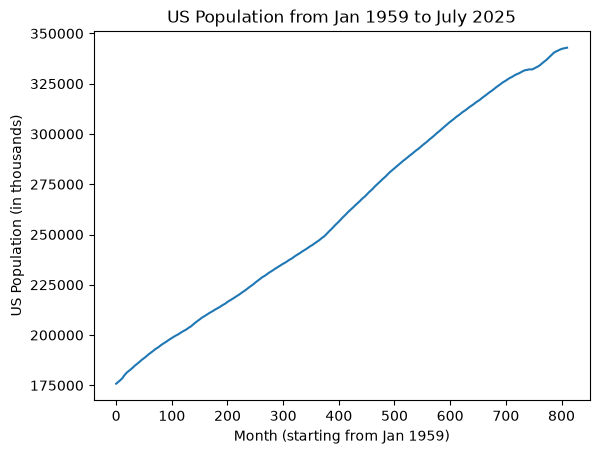

In [75]:
uspop = pd.read_csv("POPTHM_27Aug2026.csv")
print(uspop)
y = uspop['POPTHM']
n = len(y)
plt.plot(y)
plt.xlabel('Month (starting from Jan 1959)')
plt.ylabel('US Population (in thousands)')
plt.title('US Population from Jan 1959 to July 2025')
plt.show()

Let us fit the simple linear regression model to this data (with time as covariate). 

In [76]:
X = np.column_stack([np.ones(n), np.arange(1, n+1)])
linmod = sm.OLS(y, X).fit()
print(linmod.summary())

                            OLS Regression Results                            
Dep. Variable:                 POPTHM   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 2.794e+05
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:35:53   Log-Likelihood:                -7554.3
No. Observations:                 811   AIC:                         1.511e+04
Df Residuals:                     809   BIC:                         1.512e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.746e+05    189.054    923.472      0.0

The fitted regression line is plotted below along with the observed data. 

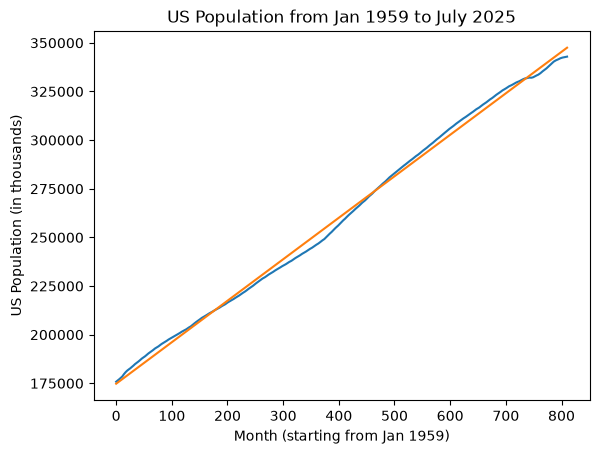

In [77]:
import matplotlib.pyplot as plt
plt.plot(y)
plt.plot(linmod.fittedvalues)
plt.xlabel('Month (starting from Jan 1959)')
plt.ylabel('US Population (in thousands)')
plt.title('US Population from Jan 1959 to July 2025')
plt.show()

We have seen that the posterior distribution of $\beta_0, \dots, \beta_m$ is given by: 
\begin{align*}
   \beta_0, \dots, \beta_m \mid \text{data} \sim t_{m+1} \left(\hat{\beta}, \frac{S(\hat{\beta})}{n-m-1} (X^T X)^{-1}, n-m-1 \right)
\end{align*}
We can generate samples from this posterior distribution and plot the resulting lines on the observed data. This will give us an idea of the uncertainty in the parameters.

In [78]:
#First we compute betahat:
betahat = linmod.params
print(betahat)
#Next we compute S(betahat):
S_betahat = np.sum(linmod.resid ** 2)
print(S_betahat)
#Next Sigma = S_betahat / (n - m - 1) * (X^T X)^{-1}:
m = X.shape[1] - 1 #in this case, m = 1
n = len(y)
Sigma = S_betahat / (n - m - 1) * np.linalg.inv(X.T @ X)
print(Sigma)

const    174585.548486
x1          213.215735
dtype: float64
5851610121.093412
[[ 3.57412307e+04 -6.60651215e+01]
 [-6.60651215e+01  1.62721974e-01]]


This matrix $\frac{S(\hat{\beta})}{n-m-1} (X^T X)^{-1}$ is actually calculated as part of the sm.OLS output, and can be obtained as follows:

In [79]:
print(linmod.cov_params()) #this coincides with Sigma calculated above. Check out help(linmod.cov_params) for more details.
print(Sigma)

              const         x1
const  35741.230736 -66.065122
x1       -66.065122   0.162722
[[ 3.57412307e+04 -6.60651215e+01]
 [-6.60651215e+01  1.62721974e-01]]


Now we need to generate observations from the $t$-distribution. For this, we shall use an inbuilt function from scipy:

In [80]:
from scipy.stats import multivariate_t
N = 1000 #number of samples to generate
beta_samples = multivariate_t.rvs(loc=betahat, shape=Sigma, df=n - m - 1, size=N)
print(beta_samples)

[[174721.3080949     213.12657353]
 [174305.73941779    213.6399766 ]
 [174822.94796507    212.62380814]
 ...
 [174662.70781635    213.3719372 ]
 [174460.98218758    213.5398607 ]
 [174747.83235296    212.89862161]]


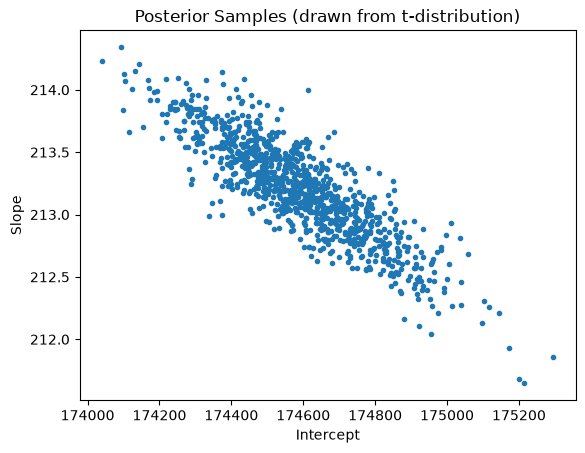

In [81]:
import matplotlib.pyplot as plt
plt.scatter(beta_samples[:,0], beta_samples[:,1], marker = '.')
plt.xlabel('Intercept')
plt.ylabel('Slope')
plt.title('Posterior Samples (drawn from t-distribution)')
plt.show()

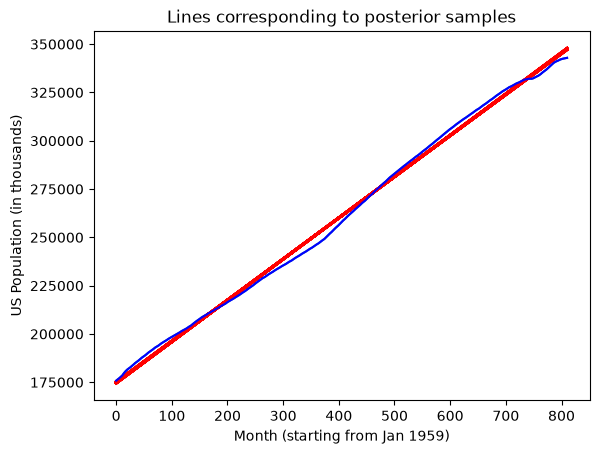

In [82]:
plt.plot(y)
for r in range(N):
    fvalsnew = np.dot(X, beta_samples[r])
    plt.plot(fvalsnew,  color = 'red')
plt.plot(y, color = 'blue')
plt.xlabel('Month (starting from Jan 1959)')
plt.ylabel('US Population (in thousands)')
plt.title('Lines corresponding to posterior samples')
plt.show()

## Dataset Two: Lake Huron Levels

    Unnamed: 0       x
0            1  580.38
1            2  581.86
2            3  580.97
3            4  580.80
4            5  579.79
..         ...     ...
93          94  578.52
94          95  579.74
95          96  579.31
96          97  579.89
97          98  579.96

[98 rows x 2 columns]


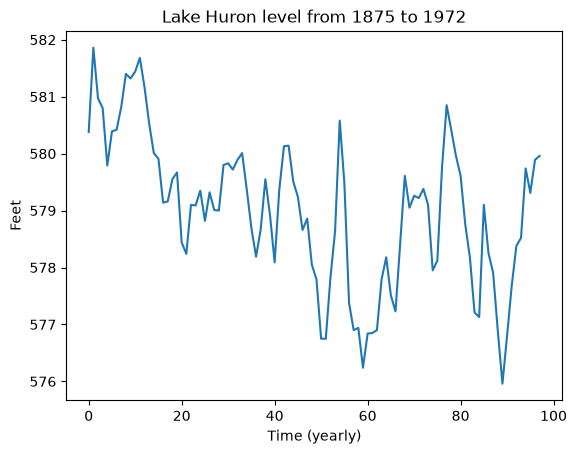

In [84]:
#Lake Huron dataset which gives annual measurements of the level (in feet) of Lake Huron from 1875 to 1972 
huron = pd.read_csv("LakeHuron.csv")
print(huron)
plt.plot(huron['x'])
plt.xlabel('Time (yearly)')
plt.ylabel('Feet')
plt.title('Lake Huron level from 1875 to 1972')
plt.show()

In [85]:
y = huron['x']
n = len(y)
x = np.arange(1, n+1)
X = np.column_stack([np.ones(n), x])
print(X)

[[ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]
 [ 1.  4.]
 [ 1.  5.]
 [ 1.  6.]
 [ 1.  7.]
 [ 1.  8.]
 [ 1.  9.]
 [ 1. 10.]
 [ 1. 11.]
 [ 1. 12.]
 [ 1. 13.]
 [ 1. 14.]
 [ 1. 15.]
 [ 1. 16.]
 [ 1. 17.]
 [ 1. 18.]
 [ 1. 19.]
 [ 1. 20.]
 [ 1. 21.]
 [ 1. 22.]
 [ 1. 23.]
 [ 1. 24.]
 [ 1. 25.]
 [ 1. 26.]
 [ 1. 27.]
 [ 1. 28.]
 [ 1. 29.]
 [ 1. 30.]
 [ 1. 31.]
 [ 1. 32.]
 [ 1. 33.]
 [ 1. 34.]
 [ 1. 35.]
 [ 1. 36.]
 [ 1. 37.]
 [ 1. 38.]
 [ 1. 39.]
 [ 1. 40.]
 [ 1. 41.]
 [ 1. 42.]
 [ 1. 43.]
 [ 1. 44.]
 [ 1. 45.]
 [ 1. 46.]
 [ 1. 47.]
 [ 1. 48.]
 [ 1. 49.]
 [ 1. 50.]
 [ 1. 51.]
 [ 1. 52.]
 [ 1. 53.]
 [ 1. 54.]
 [ 1. 55.]
 [ 1. 56.]
 [ 1. 57.]
 [ 1. 58.]
 [ 1. 59.]
 [ 1. 60.]
 [ 1. 61.]
 [ 1. 62.]
 [ 1. 63.]
 [ 1. 64.]
 [ 1. 65.]
 [ 1. 66.]
 [ 1. 67.]
 [ 1. 68.]
 [ 1. 69.]
 [ 1. 70.]
 [ 1. 71.]
 [ 1. 72.]
 [ 1. 73.]
 [ 1. 74.]
 [ 1. 75.]
 [ 1. 76.]
 [ 1. 77.]
 [ 1. 78.]
 [ 1. 79.]
 [ 1. 80.]
 [ 1. 81.]
 [ 1. 82.]
 [ 1. 83.]
 [ 1. 84.]
 [ 1. 85.]
 [ 1. 86.]
 [ 1. 87.]
 [ 1. 88.]
 [ 1. 89.]
 [ 1. 90.]
 [ 1. 91.]

In [86]:
linmod = sm.OLS(y, X).fit()
print(linmod.summary())

                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     35.95
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           3.55e-08
Time:                        19:42:35   Log-Likelihood:                -150.05
No. Observations:                  98   AIC:                             304.1
Df Residuals:                      96   BIC:                             309.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        580.2020      0.230   2521.398      0.0

In [87]:
N = 1000 #number of samples to generate
n = X.shape[0]
m = X.shape[1] - 1
beta_samples = multivariate_t.rvs(loc=linmod.params, shape=linmod.cov_params(), df=n - m - 1, size=N)
print(beta_samples)

[[ 5.79986362e+02 -2.16290863e-02]
 [ 5.79651569e+02 -1.97575824e-02]
 [ 5.80205715e+02 -2.35230973e-02]
 ...
 [ 5.80111509e+02 -1.98210127e-02]
 [ 5.80207061e+02 -2.52525258e-02]
 [ 5.80214907e+02 -2.28572556e-02]]


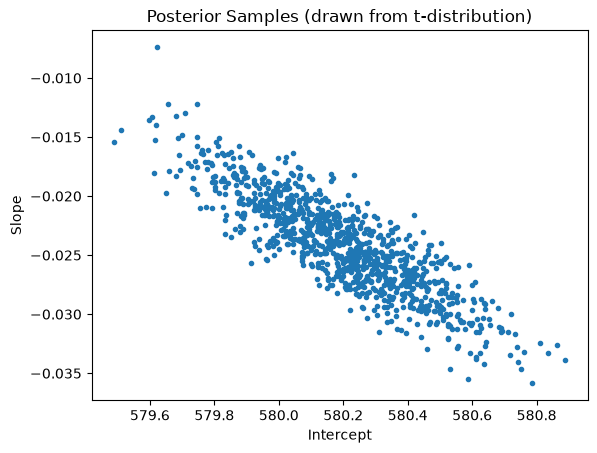

In [88]:
import matplotlib.pyplot as plt
plt.scatter(beta_samples[:,0], beta_samples[:,1], marker = '.')
plt.xlabel('Intercept')
plt.ylabel('Slope')
plt.title('Posterior Samples (drawn from t-distribution)')
plt.show()

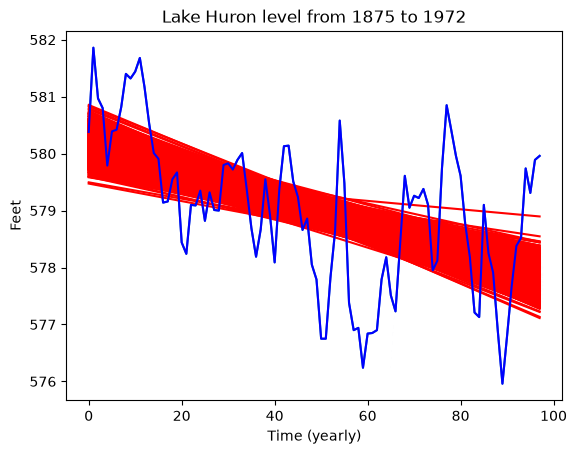

In [89]:
plt.plot(y)
for r in range(N):
    fvalsnew = np.dot(X, beta_samples[r])
    plt.plot(fvalsnew,  color = 'red')
plt.plot(y, color = 'blue')
plt.xlabel('Time (yearly)')
plt.ylabel('Feet')
plt.title('Lake Huron level from 1875 to 1972')
plt.show()

## Dataset Three: A Simulated Dataset

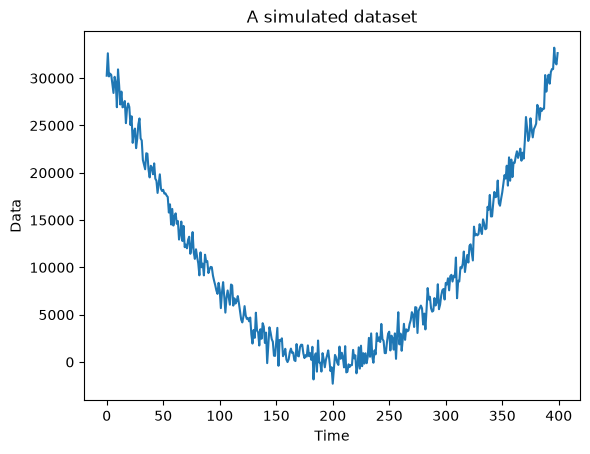

In [90]:
#A simulated dataset
n = 400
x = np.arange(1, n+1)
sig = 1000
rng = np.random.default_rng(12345)
#quadratic data with noise
y = 5 + 0.8 * ((x - (n/2)) ** 2) + rng.normal(loc = 0, scale = sig, size = n)
plt.plot(y) 
plt.xlabel("Time")
plt.ylabel("Data")
plt.title("A simulated dataset")
plt.show()

Let us fit a line (not a quadratic) to this dataset. 

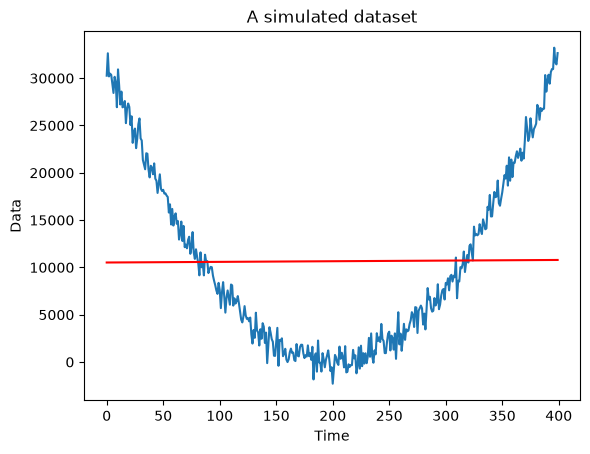

In [91]:
X = np.column_stack([np.ones(n), x])
linmod = sm.OLS(y, X).fit()
plt.plot(y)
plt.plot(linmod.fittedvalues, color = "red")
plt.xlabel("Time")
plt.ylabel("Data")
plt.title("A simulated dataset")
plt.show()

[[ 1.24847900e+04 -7.45209402e+00]
 [ 9.66084443e+03  5.88415623e+00]
 [ 1.14314746e+04 -4.28814832e+00]
 ...
 [ 1.10088743e+04 -1.72996011e+00]
 [ 1.04394835e+04  1.05566039e+00]
 [ 1.13698106e+04  1.56511066e+00]]


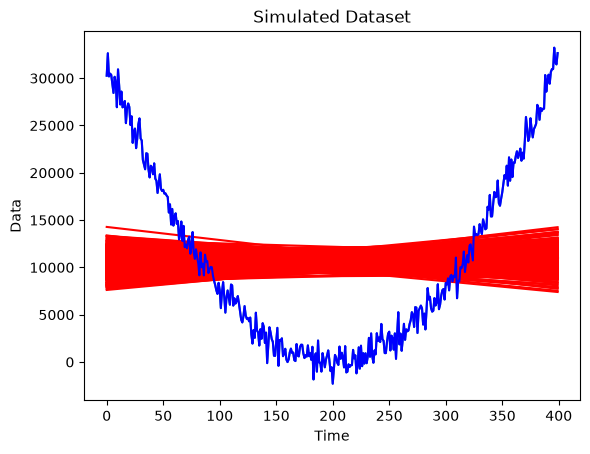

In [92]:
N = 1000 #number of samples to generate
n = X.shape[0]
m = X.shape[1] - 1
beta_samples = multivariate_t.rvs(loc=linmod.params, shape=linmod.cov_params(), df=n - m - 1, size=N)
print(beta_samples)
plt.plot(y)
for r in range(N):
    fvalsnew = np.dot(X, beta_samples[r])
    plt.plot(fvalsnew,  color = 'red')
plt.plot(y, color = 'blue')
plt.xlabel('Time')
plt.ylabel('Data')
plt.title('Simulated Dataset')
plt.show()

The correct thing here is to fit a quadratic. This is done by multiple linear regression as shown below. 

In [93]:
X  = np.column_stack([np.ones(n), x, x ** 2])
quadmod = sm.OLS(y, X).fit()
print(quadmod.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.849e+04
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:45:58   Log-Likelihood:                -3325.9
No. Observations:                 400   AIC:                             6658.
Df Residuals:                     397   BIC:                             6670.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         3.2e+04    149.517    214.033      0.0

[[ 3.18471308e+04 -3.17976656e+02  7.94430399e-01]
 [ 3.19486063e+04 -3.20504111e+02  8.01512967e-01]
 [ 3.20846821e+04 -3.20623326e+02  8.01345909e-01]
 ...
 [ 3.22390951e+04 -3.21993886e+02  8.03728479e-01]
 [ 3.18593038e+04 -3.18269400e+02  7.95333099e-01]
 [ 3.18704431e+04 -3.19046782e+02  7.98341252e-01]]


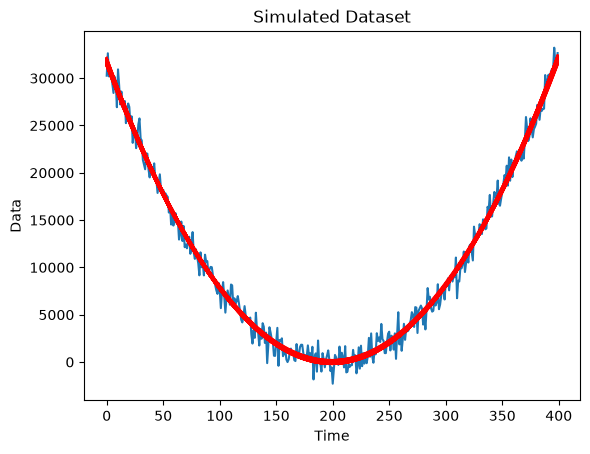

In [94]:
N = 1000 #number of samples to generate
n = X.shape[0]
m = X.shape[1] - 1
beta_samples = multivariate_t.rvs(loc=quadmod.params, shape=quadmod.cov_params(), df=n - m - 1, size=N)
print(beta_samples)
plt.plot(y)
for r in range(N):
    fvalsnew = np.dot(X, beta_samples[r])
    plt.plot(fvalsnew,  color = 'red')
#plt.plot(y, color = 'blue')
plt.xlabel('Time')
plt.ylabel('Data')
plt.title('Simulated Dataset')
plt.show()

### Standard Errors and Intervals in Regression

Consider the simple linear regression model: 
\begin{align*}
   y_t = \beta_0 + \beta_1 t + \epsilon_t
\end{align*}
that we used in Lecture 2 for the US population dataset. 

In [95]:
uspop = pd.read_csv('POPTHM_27Aug2026.csv')
y = uspop['POPTHM']
n = len(y)
x = np.arange(1, n + 1)
X = np.column_stack([np.ones(n),x])

md1 = sm.OLS(y, X).fit()
print(md1.summary())

                            OLS Regression Results                            
Dep. Variable:                 POPTHM   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 2.794e+05
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:46:45   Log-Likelihood:                -7554.3
No. Observations:                 811   AIC:                         1.511e+04
Df Residuals:                     809   BIC:                         1.512e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.746e+05    189.054    923.472      0.0

The output above reports that the standard error corresponding to the estimate for $\beta_1$ is 0.403 and the 95% interval for $\beta_1$ is $[212.424, 214.008]$. These quantities can also be obtained from the regression output as follows. 

In [96]:
print(md1.params) #these are the betahats (least squares estimates)
print(md1.bse) #these are the standard errors of the betahats
print(md1.conf_int(alpha=0.05)) #these are the 95% confidence intervals

const    174585.548486
x1          213.215735
dtype: float64
const    189.053513
x1         0.403388
dtype: float64
                   0              1
const  174214.455222  174956.641750
x1        212.423924     214.007546


We can obtain these manually using the formulae that we derived and check if we are getting exactly the same answers. 

In [97]:
#For betahat: 
betahat = np.linalg.inv(X.T @ X) @ X.T @ y
print(betahat)
print(md1.params) #these are the betahats (least squares estimates)


[174585.54848609    213.21573493]
const    174585.548486
x1          213.215735
dtype: float64


In [98]:
#For standard errors:
residuals = y - X @ betahat
sigma2hat = (residuals.T @ residuals) / (n - X.shape[1])
var_betahat = sigma2hat * np.linalg.inv(X.T @ X)
se_betahat = np.sqrt(np.diag(var_betahat))
print(se_betahat)
print(md1.bse) #these are the standard errors of the betahats

[189.05351289   0.40338812]
const    189.053513
x1         0.403388
dtype: float64


In [99]:
#For confidence intervals:
from scipy.stats import t
alpha = 0.05
t_critical = t.ppf(1 - alpha/2, df=n - X.shape[1]) #this computes t_{df, 1-alpha/2}
conf_int_lower = betahat - t_critical * se_betahat
conf_int_upper = betahat + t_critical * se_betahat
conf_int = np.column_stack((conf_int_lower, conf_int_upper))
print(conf_int)
print(md1.conf_int(alpha=0.05)) #these are the 95% confidence intervals

[[174214.45522237 174956.64174982]
 [   212.42392413    214.00754573]]
                   0              1
const  174214.455222  174956.641750
x1        212.423924     214.007546
